<a href="https://colab.research.google.com/github/timofei-treves/ChurnPredictor/blob/main/%D0%9F%D0%B5%D1%80%D0%B2%D0%B8%D1%87%D0%BD%D1%8B%D0%B9_%D1%80%D0%B0%D0%B7%D0%B2%D0%B5%D0%B4%D0%BE%D1%87%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Прогнозирование оттока клиентов KKBox
## 1. Загрузка и первичный анализ данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Настройки отображения
pd.set_option('display.max_columns', 100)
plt.style.use('ggplot')
%matplotlib inline

### 1.1. Загрузка train-данных

In [ ]:
# Загружаем обучающую выборку (целевая переменная для марта 2017)
train = pd.read_csv('/content/train_v2.csv')
print(f"Train shape: {train.shape}")
print(f"Train columns: {train.columns.tolist()}")
print(f"Распределение целевой переменной:\n{train['is_churn'].value_counts(normalize=True)}")

Train shape: (970960, 2)
Train columns: ['msno', 'is_churn']
Распределение целевой переменной:
is_churn
0    0.910058
1    0.089942
Name: proportion, dtype: float64


### 1.2. Загрузка информации о пользователях (members)

In [ ]:
# Загружаем members_v3.csv
members = pd.read_csv('/content/members_v3.csv')
print(f"Members shape: {members.shape}")
print(members.head())

Members shape: (6769473, 6)
                                           msno  city  bd  gender  \
0  Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=     1   0     NaN   
1  +tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=     1   0     NaN   
2  cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=     1   0     NaN   
3  9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=     1   0     NaN   
4  WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=     6  32  female   

   registered_via  registration_init_time  
0              11                20110911  
1               7                20110914  
2              11                20110915  
3              11                20110915  
4               9                20110915  


In [ ]:
# Обработка возраста: очистка выбросов
# По описанию, возраст может быть от -7000 до 2015. Оставляем разумный диапазон (0-100 лет)
members['bd'] = members['bd'].astype(float)
members.loc[(members['bd'] < 0) | (members['bd'] > 100), 'bd'] = np.nan
print(f"Пропуски в возрасте после очистки: {members['bd'].isnull().sum()}")

Пропуски в возрасте после очистки: 5651


In [ ]:
# Заполним пропуски медианой по городу и полу (можно и просто медианой)
members['bd'] = members.groupby(['city', 'gender'])['bd'].transform(lambda x: x.fillna(x.median()))
members['bd'] = members['bd'].fillna(members['bd'].median())  # если остались пропуски

# Категориальные признаки: city, gender, registered_via
# Заполним пропуски в поле gender модой
members['gender'].fillna(members['gender'].mode()[0], inplace=True)

# Преобразуем registration_init_time в datetime (год-месяц-день)
members['registration_init_time'] = pd.to_datetime(members['registration_init_time'], format='%Y%m%d', errors='coerce')
print(f"Диапазон дат регистрации: {members['registration_init_time'].min()} - {members['registration_init_time'].max()}")

Диапазон дат регистрации: 2004-03-26 00:00:00 - 2017-04-29 00:00:00


### 1.3. Загрузка и агрегация транзакций

In [ ]:
# Транзакции до 31.03.2017
transactions = pd.read_csv('/content/transactions_v2.csv')
print(f"Transactions shape: {transactions.shape}")
print(transactions.head())

Transactions shape: (1431009, 9)
                                           msno  payment_method_id  \
0  ++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=                 32   
1  ++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=                 41   
2  +/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=                 36   
3  +/w1UrZwyka4C9oNH3+Q8fUf3fD8R3EwWrx57ODIsqk=                 36   
4  +00PGzKTYqtnb65mPKPyeHXcZEwqiEzktpQksaaSC3c=                 41   

   payment_plan_days  plan_list_price  actual_amount_paid  is_auto_renew  \
0                 90              298                 298              0   
1                 30              149                 149              1   
2                 30              180                 180              1   
3                 30              180                 180              1   
4                 30               99                  99              1   

   transaction_date  membership_expire_date  is_cancel  
0          20170131             

In [ ]:
# Преобразуем даты
date_cols = ['transaction_date', 'membership_expire_date']
for col in date_cols:
    transactions[col] = pd.to_datetime(transactions[col], format='%Y%m%d', errors='coerce')

# Проверим, что даты в пределах разумного
print(f"transaction_date: {transactions['transaction_date'].min()} - {transactions['transaction_date'].max()}")
print(f"membership_expire_date: {transactions['membership_expire_date'].min()} - {transactions['membership_expire_date'].max()}")

transaction_date: 2015-01-01 00:00:00 - 2017-03-31 00:00:00
membership_expire_date: 2016-04-19 00:00:00 - 2036-10-15 00:00:00


In [ ]:
# Создадим признаки для каждого пользователя
# Группируем по msno и агрегируем
agg_trans = transactions.groupby('msno').agg(
    txn_count=('msno', 'count'),
    txn_plan_days_mean=('payment_plan_days', 'mean'),
    txn_plan_days_std=('payment_plan_days', 'std'),
    txn_plan_days_max=('payment_plan_days', 'max'),
    txn_plan_days_min=('payment_plan_days', 'min'),
    txn_list_price_mean=('plan_list_price', 'mean'),
    txn_list_price_std=('plan_list_price', 'std'),
    txn_actual_amount_mean=('actual_amount_paid', 'mean'),
    txn_actual_amount_std=('actual_amount_paid', 'std'),
    txn_auto_renew_rate=('is_auto_renew', 'mean'),  # доля транзакций с авто-продлением
    txn_cancel_rate=('is_cancel', 'mean'),          # доля отмен
    txn_last_transaction_date=('transaction_date', 'max'),
    txn_last_expire_date=('membership_expire_date', 'max'),
    txn_first_transaction_date=('transaction_date', 'min')
).reset_index()

In [ ]:
# Добавим признак: сколько дней прошло с последней транзакции до "конца истории" (31.03.2017)
# Это может быть важно для прогноза
last_known_date = pd.Timestamp('2017-03-31')
agg_trans['txn_days_since_last'] = (last_known_date - agg_trans['txn_last_transaction_date']).dt.days

# Также разница между последней датой истечения и последней транзакцией
agg_trans['txn_expire_minus_transaction'] = (agg_trans['txn_last_expire_date'] - agg_trans['txn_last_transaction_date']).dt.days

print(f"Агрегированные транзакции: {agg_trans.shape}")

Агрегированные транзакции: (1197050, 17)


### 1.4. Загрузка и агрегация логов прослушивания (самый большой файл)

In [ ]:
# Для оптимизации загружаем только нужные колонки и используем чанки

# Сначала посмотрим на первые строки
user_logs = pd.read_csv('/content/user_logs_v2.csv', nrows=5)
print(user_logs.head())

                                           msno      date  num_25  num_50  \
0  u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=  20170331       8       4   
1  nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=  20170330       2       2   
2  2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=  20170331      52       3   
3  ycwLc+m2O0a85jSLALtr941AaZt9ai8Qwlg9n0Nql5U=  20170331     176       4   
4  EGcbTofOSOkMmQyN1NMLxHEXJ1yV3t/JdhGwQ9wXjnI=  20170331       2       1   

   num_75  num_985  num_100  num_unq  total_secs  
0       0        1       21       18    6309.273  
1       1        0        9       11    2390.699  
2       5        3       84      110   23203.337  
3       2        2       19      191    7100.454  
4       0        1      112       93   28401.558  


In [ ]:
# Определим типы для экономии памяти
dtypes_logs = {
    'msno': 'object',
    'num_25': 'int32',
    'num_50': 'int32',
    'num_75': 'int32',
    'num_985': 'int32',
    'num_100': 'int32',
    'num_unq': 'int32',
    'total_secs': 'float32'
}

In [ ]:
chunk_size = 500000  # размер чанка
agg_chunks = []      # список для хранения результатов каждого чанка

# Читаем файл чанками
with pd.read_csv('/content/user_logs_v2.csv',
                 dtype=dtypes_logs,
                 chunksize=chunk_size) as reader:

    for chunk in tqdm(reader):
        # Преобразуем дату в datetime
        chunk['date'] = pd.to_datetime(chunk['date'], format='%Y%m%d', errors='coerce')

        # Группируем по пользователю внутри текущего чанка
        chunk_agg = chunk.groupby('msno').agg(
            logs_days=('date', 'nunique'),
            logs_total_secs=('total_secs', 'sum'),
            logs_avg_secs_per_day=('total_secs', lambda x: x.sum() / x.count() if x.count() > 0 else 0),
            logs_total_unq=('num_unq', 'sum'),
            logs_avg_unq_per_day=('num_unq', lambda x: x.sum() / x.count() if x.count() > 0 else 0),
            logs_num25_sum=('num_25', 'sum'),
            logs_num50_sum=('num_50', 'sum'),
            logs_num75_sum=('num_75', 'sum'),
            logs_num985_sum=('num_985', 'sum'),
            logs_num100_sum=('num_100', 'sum'),
            logs_last_date=('date', 'max')
        ).reset_index()

        # Заменяем возможные NaN в средних значениях на 0 (на всякий случай)
        chunk_agg['logs_avg_secs_per_day'] = chunk_agg['logs_avg_secs_per_day'].fillna(0)
        chunk_agg['logs_avg_unq_per_day'] = chunk_agg['logs_avg_unq_per_day'].fillna(0)

        agg_chunks.append(chunk_agg)

# Объединяем все чанки
agg_logs = pd.concat(agg_chunks, ignore_index=True)

37it [34:24, 55.80s/it]


In [ ]:
# Финальная агрегация по пользователям (так как один пользователь мог встретиться в нескольких чанках)
agg_logs = agg_logs.groupby('msno').agg(
    logs_days=('logs_days', 'sum'),
    logs_total_secs=('logs_total_secs', 'sum'),
    logs_avg_secs_per_day=('logs_avg_secs_per_day', 'mean'),  # среднее из средних? лучше пересчитать
    logs_total_unq=('logs_total_unq', 'sum'),
    logs_avg_unq_per_day=('logs_avg_unq_per_day', 'mean'),
    logs_num25_sum=('logs_num25_sum', 'sum'),
    logs_num50_sum=('logs_num50_sum', 'sum'),
    logs_num75_sum=('logs_num75_sum', 'sum'),
    logs_num985_sum=('logs_num985_sum', 'sum'),
    logs_num100_sum=('logs_num100_sum', 'sum'),
    logs_last_date=('logs_last_date', 'max')
).reset_index()

In [ ]:
# Пересчёт правильных средних (более точно)
agg_logs['logs_avg_secs_per_day'] = agg_logs['logs_total_secs'] / agg_logs['logs_days']
agg_logs['logs_avg_secs_per_day'].replace([np.inf, -np.inf], 0, inplace=True)
agg_logs['logs_avg_secs_per_day'].fillna(0, inplace=True)

agg_logs['logs_avg_unq_per_day'] = agg_logs['logs_total_unq'] / agg_logs['logs_days']
agg_logs['logs_avg_unq_per_day'].replace([np.inf, -np.inf], 0, inplace=True)
agg_logs['logs_avg_unq_per_day'].fillna(0, inplace=True)

In [ ]:
# Добавим признак: доля песен, прослушанных почти полностью (num100 / total)
total_plays = agg_logs[['logs_num25_sum', 'logs_num50_sum', 'logs_num75_sum',
                        'logs_num985_sum', 'logs_num100_sum']].sum(axis=1)
agg_logs['logs_completion_ratio'] = agg_logs['logs_num100_sum'] / total_plays
agg_logs['logs_completion_ratio'].fillna(0, inplace=True)

In [ ]:
# Сохраняем результат на диск
agg_logs.to_csv('agg_logs_v2.csv', index=False)
print(f"Всего уникальных пользователей в логах: {len(agg_logs)}")

Всего уникальных пользователей в логах: 1103894


### 1.5. Объединение всех таблиц

In [ ]:
# Начинаем с train
data = train.copy()

# Присоединяем members
data = data.merge(members, on='msno', how='left')
print(f"После members: {data.shape}")

# Присоединяем агрегированные транзакции
data = data.merge(agg_trans, on='msno', how='left')
print(f"После транзакций: {data.shape}")

# Присоединяем агрегированные логи
data = data.merge(agg_logs, on='msno', how='left')
print(f"После логов: {data.shape}")

После members: (970960, 7)
После транзакций: (970960, 23)
После логов: (970960, 35)


In [ ]:
# Посмотрим на пропуски
missing = data.isnull().sum()
missing_percent = missing / len(data) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'percent': missing_percent})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False))

                              missing_count    percent
txn_plan_days_std                    854971  88.054194
txn_actual_amount_std                854971  88.054194
txn_list_price_std                   854971  88.054194
logs_avg_unq_per_day                 216409  22.288148
logs_num75_sum                       216409  22.288148
logs_completion_ratio                216409  22.288148
logs_last_date                       216409  22.288148
logs_num100_sum                      216409  22.288148
logs_num985_sum                      216409  22.288148
logs_days                            216409  22.288148
logs_num25_sum                       216409  22.288148
logs_num50_sum                       216409  22.288148
logs_total_unq                       216409  22.288148
logs_avg_secs_per_day                216409  22.288148
logs_total_secs                      216409  22.288148
city                                 109993  11.328273
bd                                   109993  11.328273
gender    

In [ ]:
# Некоторые пользователи могут не иметь транзакций или логов (пропуски). Заполним нулями, где уместно.
# Например, для числовых признаков из транзакций и логов можно заполнить 0, а для дат оставить NaN.
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
# Исключим целевую переменную и возможные идентификаторы
num_cols = [c for c in num_cols if c not in ['is_churn']]
data[num_cols] = data[num_cols].fillna(0)

# Проверим размер итогового датасета
print(f"Итоговый размер данных для моделирования: {data.shape}")

Итоговый размер данных для моделирования: (970960, 35)


### 1.6. Первичный разведочный анализ (EDA)

In [ ]:
# Посмотрим на типы данных и базовые статистики
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   msno                          970960 non-null  object        
 1   is_churn                      970960 non-null  int64         
 2   city                          970960 non-null  float64       
 3   bd                            970960 non-null  float64       
 4   gender                        860967 non-null  object        
 5   registered_via                970960 non-null  float64       
 6   registration_init_time        860967 non-null  datetime64[ns]
 7   txn_count                     970960 non-null  float64       
 8   txn_plan_days_mean            970960 non-null  float64       
 9   txn_plan_days_std             970960 non-null  float64       
 10  txn_plan_days_max             970960 non-null  float64       
 11  txn_plan_days

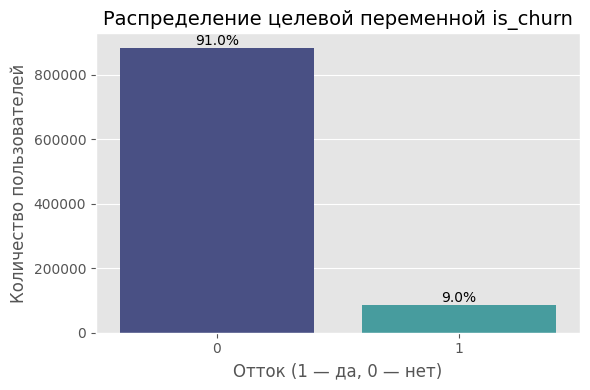

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x='is_churn', data=data, palette='mako')
plt.title('Распределение целевой переменной is_churn', fontsize=14)
plt.xlabel('Отток (1 — да, 0 — нет)', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)

total = len(data)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height/total*100:.1f}%',
                       (p.get_x() + p.get_width()/2., height),
                       ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('figure_2_1_churn_distribution.png', dpi=300)
plt.show()

In [17]:
print(f"Доля оттока в объединённом датасете: {data['is_churn'].mean() * 100:.2f}%")

Доля оттока в объединённом датасете: 8.99%


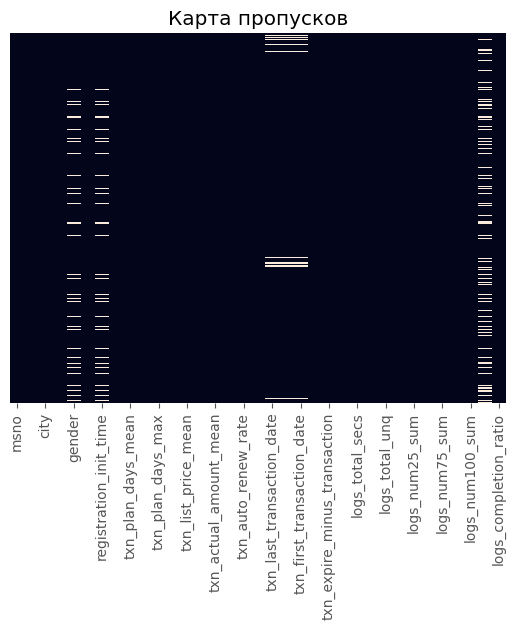

In [18]:
# Визуализация пропусков (после заполнения нулями пропусков нет, но проверим)
sns.heatmap(data.isnull(), cbar=False, yticklabels=False)
plt.title('Карта пропусков')
plt.show()

<Figure size 800x400 with 0 Axes>

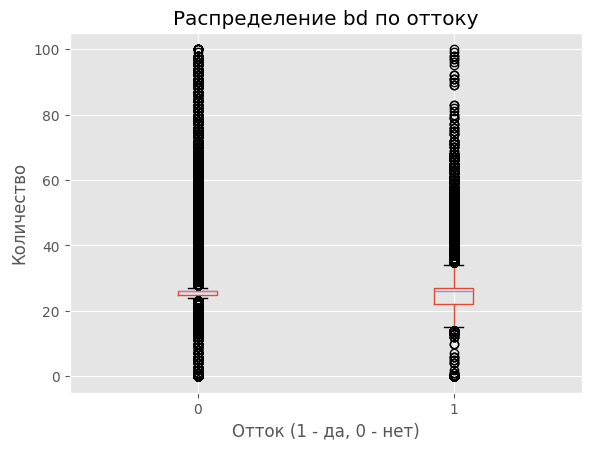

<Figure size 800x400 with 0 Axes>

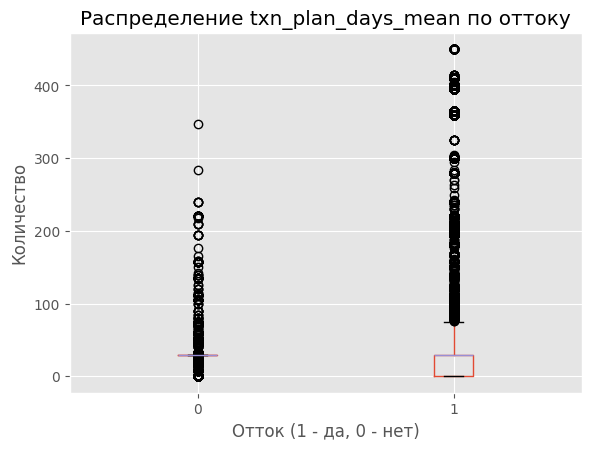

<Figure size 800x400 with 0 Axes>

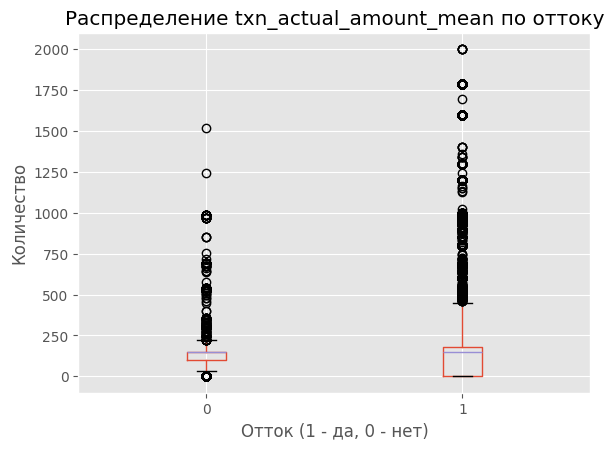

<Figure size 800x400 with 0 Axes>

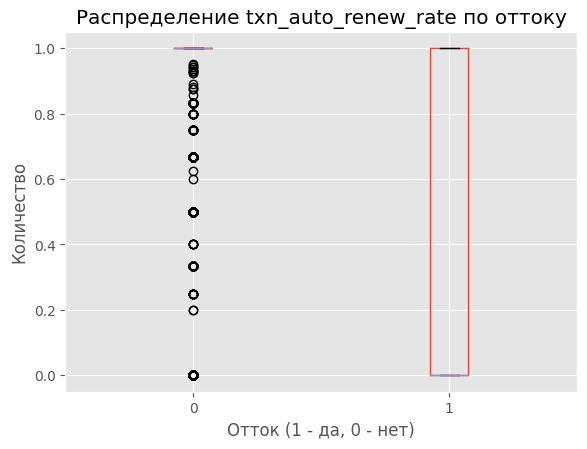

<Figure size 800x400 with 0 Axes>

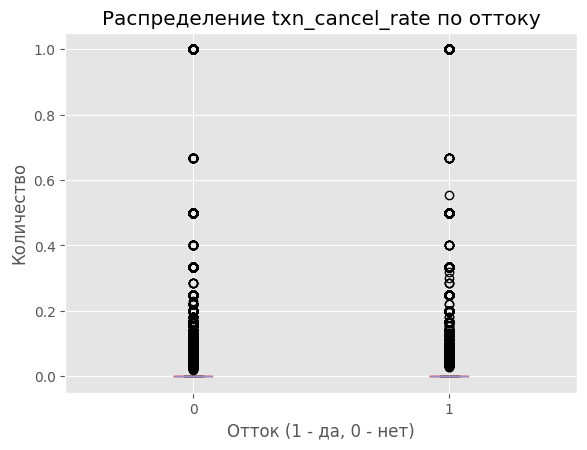

<Figure size 800x400 with 0 Axes>

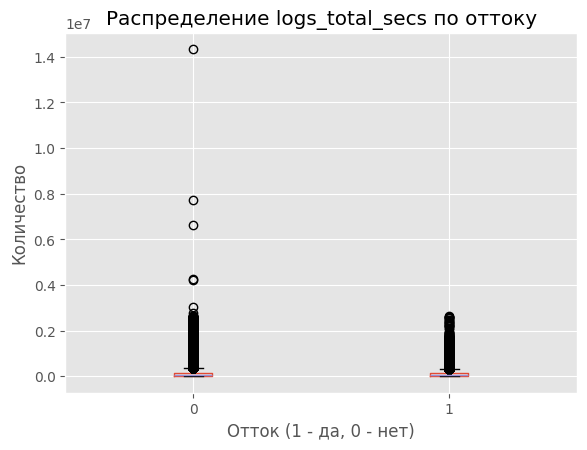

<Figure size 800x400 with 0 Axes>

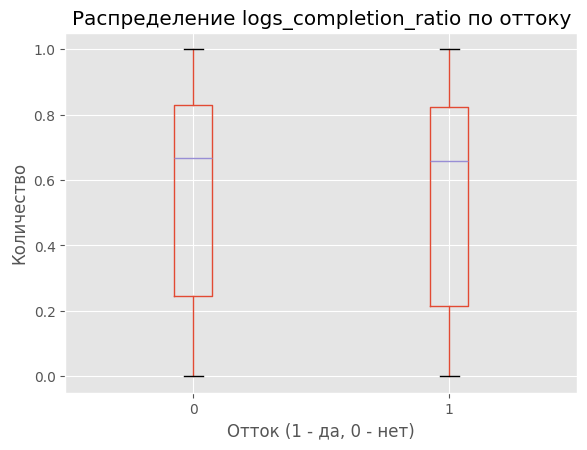

<Figure size 800x400 with 0 Axes>

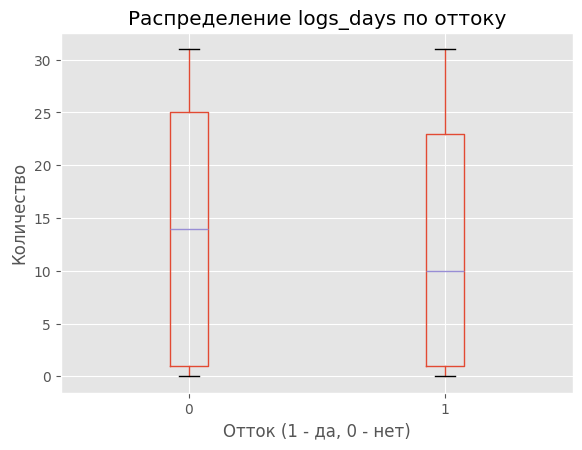

In [19]:
# Анализ числовых признаков в разрезе оттока
# Выберем несколько интересных признаков
features_to_plot = ['bd', 'txn_plan_days_mean', 'txn_actual_amount_mean', 'txn_auto_renew_rate',
                    'txn_cancel_rate', 'logs_total_secs', 'logs_completion_ratio', 'logs_days']

for feat in features_to_plot:
    plt.figure(figsize=(8, 4))
    data.boxplot(column=feat, by='is_churn')
    plt.title(f'Распределение {feat} по оттоку')
    plt.suptitle('')
    plt.xlabel('Отток (1 - да, 0 - нет)')
    plt.ylabel('Количество')
    plt.show()

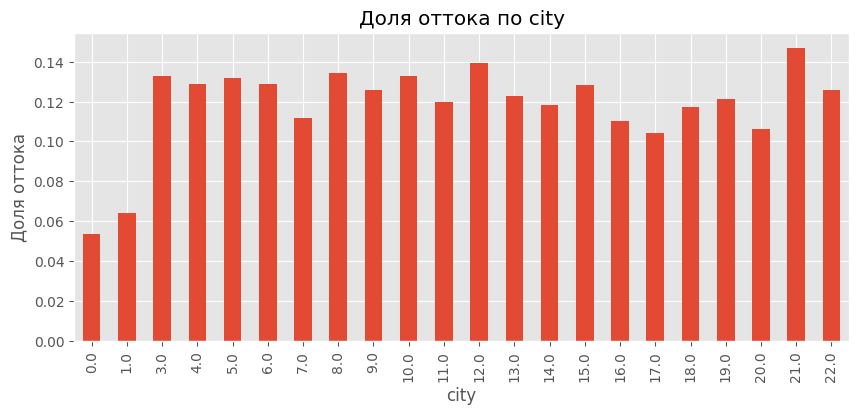

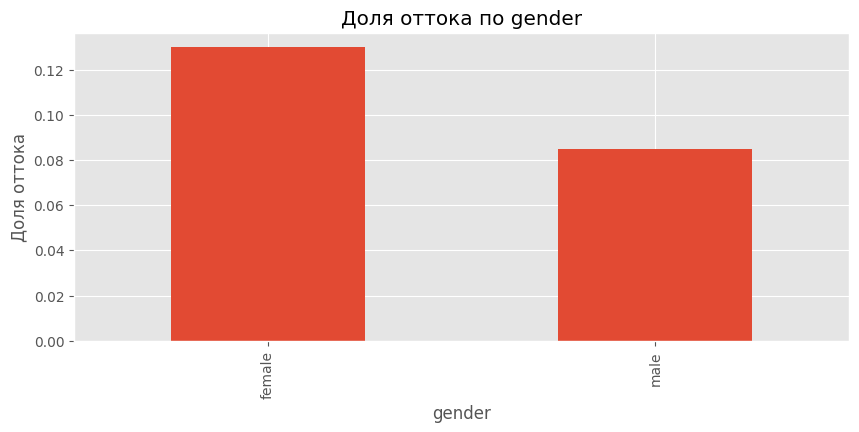

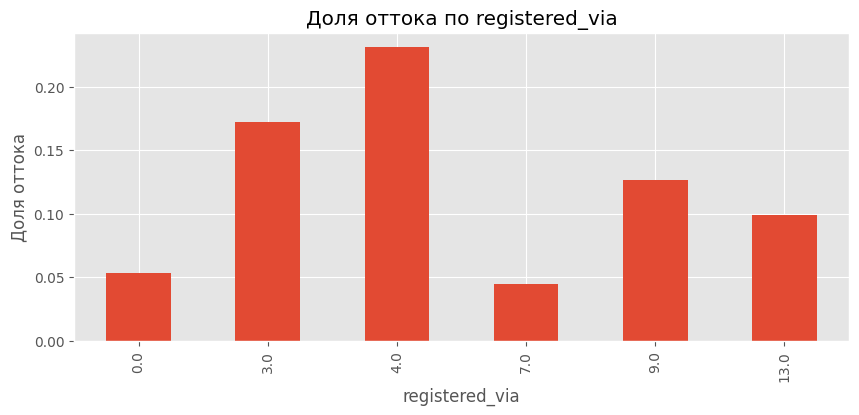

In [20]:
# Категориальные признаки: city, gender, registered_via
cat_feats = ['city', 'gender', 'registered_via']
for feat in cat_feats:
    plt.figure(figsize=(10, 4))
    data.groupby(feat)['is_churn'].mean().plot(kind='bar')
    plt.title(f'Доля оттока по {feat}')
    plt.ylabel('Доля оттока')
    plt.show()

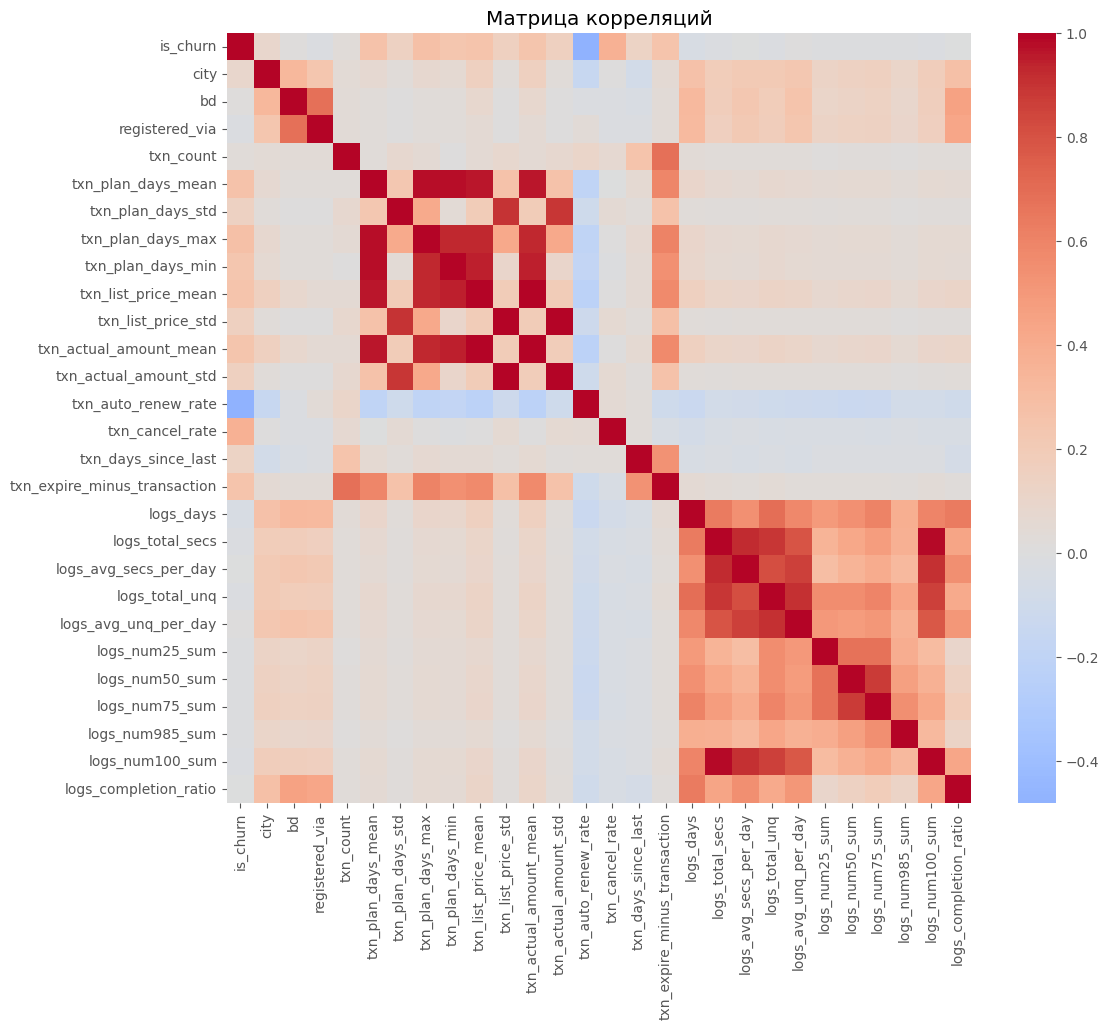

In [21]:
# Корреляционная матрица (только числовые)
plt.figure(figsize=(12, 10))
corr = data.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

In [22]:
corr_matrix = data[['logs_days', 'logs_total_secs']].corr()
print(corr_matrix)

                 logs_days  logs_total_secs
logs_days         1.000000         0.631892
logs_total_secs   0.631892         1.000000


In [23]:
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

# Если есть is_churn, временно убираем его, чтобы не искать корреляцию с самим собой
cols_without_target = [col for col in numeric_cols if col != 'is_churn']

corr_matrix = data[cols_without_target].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
abs_corr = corr_matrix.where(mask).abs().unstack()

# Находим максимальное значение и соответствующую пару признаков
max_corr = abs_corr.max()
pair = abs_corr.idxmax()

print(f"Самая сильная корреляция (по модулю) между признаками: {pair[0]} и {pair[1]}")
print(f"Коэффициент корреляции Пирсона: {max_corr:.4f}")

Самая сильная корреляция (по модулю) между признаками: txn_actual_amount_mean и txn_list_price_mean
Коэффициент корреляции Пирсона: 0.9989


In [24]:
target_corr = data[['is_churn', 'txn_auto_renew_rate', 'txn_cancel_rate', 'logs_total_secs']].corr()

corr_with_target = target_corr['is_churn'].drop('is_churn')

print("\nКорреляции целевой переменной с выбранными признаками:")
print(corr_with_target.round(4))


Корреляции целевой переменной с выбранными признаками:
txn_auto_renew_rate   -0.4804
txn_cancel_rate        0.3655
logs_total_secs       -0.0196
Name: is_churn, dtype: float64


### 1.7. Сохранение обработанного датасета для дальнейшего моделирования

In [ ]:
data.to_csv('processed_train_v2.csv', index=False)
print("Обработанные данные сохранены.")

Обработанные данные сохранены.


Для повторного обращения к данным для построения графиков и цифр


In [13]:
data = pd.read_csv('/content/processed_train_v2.csv')

In [14]:
# ===================================================
# Проверка всех ключевых числовых результатов EDA
# ===================================================

# 1. Доля оттока
churn_rate = data['is_churn'].mean() * 100
churn_count = data['is_churn'].sum()
total_count = len(data)
print(f"1. Доля оттока: {churn_rate:.2f}% ({churn_count} из {total_count})")

# 2. Самая сильная корреляция между признаками
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
if 'is_churn' in numeric_cols:
    numeric_cols.remove('is_churn')
corr_matrix = data[numeric_cols].corr()
# Маска для верхнего треугольника без диагонали
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
abs_corr = corr_matrix.where(mask).abs().unstack()
if not abs_corr.empty:
    max_corr = abs_corr.max()
    pair = abs_corr.idxmax()
    print(f"\n2. Самая сильная корреляция между признаками: {pair[0]} и {pair[1]} = {max_corr:.4f}")
    # Проверка количества ненулевых пар
    valid_pairs = data[[pair[0], pair[1]]].dropna().shape[0]
    print(f"   Количество наблюдений (без пропусков): {valid_pairs}")
else:
    print("\n2. Нет пар для корреляции (возможно, только один признак)")

# 3. Корреляции целевой переменной
if 'is_churn' in data.columns:
    target_corr = data[['is_churn', 'txn_auto_renew_rate', 'txn_cancel_rate', 'logs_total_secs']].corr()['is_churn'].drop('is_churn')
    print("\n3. Корреляции с is_churn:")
    print(f"   txn_auto_renew_rate: {target_corr['txn_auto_renew_rate']:.4f}")
    print(f"   txn_cancel_rate: {target_corr['txn_cancel_rate']:.4f}")
    print(f"   logs_total_secs: {target_corr['logs_total_secs']:.4f}")

# 4. Доля пропусков в ключевых признаках
print("\n4. Доля пропусков (%) в итоговом датасете:")
key_cols = ['txn_plan_days_std', 'logs_avg_unq_per_day', 'city', 'bd', 'txn_last_transaction_date']
for col in key_cols:
    if col in data.columns:
        missing = data[col].isnull().mean() * 100
        print(f"   {col}: {missing:.2f}%")

# 5. Медианные значения ключевых признаков в разрезе оттока
print("\n5. Медианные значения признаков (остались vs ушли):")
features = ['bd', 'txn_plan_days_mean', 'txn_actual_amount_mean', 'logs_total_secs', 'logs_days', 'logs_completion_ratio']
for feat in features:
    if feat in data.columns:
        median_0 = data[data['is_churn']==0][feat].median()
        median_1 = data[data['is_churn']==1][feat].median()
        print(f"   {feat}: остались = {median_0:.2f}, ушли = {median_1:.2f}")

# 6. Доля оттока по категориальным признакам
print("\n6. Доля оттока по категориям:")
for cat in ['city', 'gender', 'registered_via']:
    if cat in data.columns:
        churn_by_cat = data.groupby(cat)['is_churn'].mean().sort_values(ascending=False)
        print(f"\n   {cat}: max = {churn_by_cat.max():.3f} (категория {churn_by_cat.idxmax()}), min = {churn_by_cat.min():.3f} (категория {churn_by_cat.idxmin()})")

# 7. Количество записей в итоговом датасете
print(f"\n7. Итоговый датасет содержит {len(data):,} записей.")

1. Доля оттока: 8.99% (87330 из 970960)

2. Самая сильная корреляция между признаками: txn_actual_amount_mean и txn_list_price_mean = 0.9989
   Количество наблюдений (без пропусков): 970960

3. Корреляции с is_churn:
   txn_auto_renew_rate: -0.4804
   txn_cancel_rate: 0.3655
   logs_total_secs: -0.0196

4. Доля пропусков (%) в итоговом датасете:
   txn_plan_days_std: 0.00%
   logs_avg_unq_per_day: 0.00%
   city: 0.00%
   bd: 0.00%
   txn_last_transaction_date: 3.85%

5. Медианные значения признаков (остались vs ушли):
   bd: остались = 26.00, ушли = 26.00
   txn_plan_days_mean: остались = 30.00, ушли = 30.00
   txn_actual_amount_mean: остались = 149.00, ушли = 149.00
   logs_total_secs: остались = 51167.39, ушли = 38419.62
   logs_days: остались = 14.00, ушли = 10.00
   logs_completion_ratio: остались = 0.67, ушли = 0.66

6. Доля оттока по категориям:

   city: max = 0.147 (категория 21.0), min = 0.053 (категория 0.0)

   gender: max = 0.130 (категория female), min = 0.085 (категория m